# Module 10 portfolio — Time-varying interaction strengths in dairy-cow thermoregulation

**Course:** Complex Systems · Module 10 — Empirical Dynamic Modeling
**Reference paper:** Chang, C. W., Ushio, M., & Hsieh, C. H. (2017). *Empirical dynamic modeling for beginners*. Ecological Research, 32(6), 785–796.
**Slide-53 question addressed:** *"Are there any features of your data that indicate over time it becomes less predictable (e.g., looking at the time-varying RMSE or MAE), or that interaction strength changes? What might be going on at such times?"*

**Dataset:** MmCows — a multi-modal dairy cattle sensor dataset with rumen-bolus core body temperature (CBT), ankle accelerometer, UWB indoor positioning, and barn-average temperature-humidity index (THI). Window: 2023-07-21 → 2023-08-04 (14 days). Cows: C01–C05 panel.

**Headline claim.** Dairy cows are a textbook state-dependent dynamical system: thermoregulation, behavior, and the herd's environmental state are nonlinearly coupled, and the strength of that coupling depends on which region of state space the animal currently occupies. We use S-Map (Sugihara 1994) on a multivariate embedding of CBT to estimate **time-varying Jacobian coefficients** — local linear sensitivities $\partial \mathrm{CBT}/\partial v$ for each predictor variable $v$ — and ask whether they reorganise across a documented heat-stress window. This is the slide-45 *"tracking interaction strength"* method applied to real physiological data.

**Why this is a useful test of EDM concepts.** Three threads from the lecture converge:
1. *State dependence* (slide 8, 25): a system whose interaction structure changes with the local state cannot be modelled by a single global linear regression. S-Map's locally-weighted neighbours capture exactly this.
2. *Mirage correlations* (slide 8): a global Pearson correlation between THI and CBT will hide the fact that the coupling is much stronger inside the heat-stress regime than outside it. S-Map Jacobians make this visible.
3. *Mechanistic understanding* (slide 8): if $\partial\mathrm{CBT}/\partial\mathrm{THI}$ spikes during hot days and is near-zero on cool days, we have an operational, data-driven definition of when the cow is *thermally challenged* — useful for welfare-monitoring policy.

## 1 · EDM concepts used in this notebook

A short refresher on the pieces we'll actually call:

**Takens' (1981) embedding theorem.** For a deterministic system on a $d$-dimensional manifold, a delay-coordinate embedding of any sufficiently smooth observable preserves the topology of the attractor when $E\ge 2d+1$. Local neighbourhoods in the shadow manifold map to local neighbourhoods of the original system, so we can do *local* prediction, *local* regression, and *local* Jacobian estimation directly on lagged copies of measured signals — without a model of the underlying dynamics.

**Simplex projection (Sugihara & May 1990).** Pick the embedding dimension $E$ that maximises one-step-ahead out-of-sample $\rho$. A model-free predictability dimension.

**S-Map (Sugihara 1994).** Local linear regression in state space, with neighbour weights $w_i=\exp(-\theta\, d_i/\bar d)$. The locality parameter $\theta$ controls state-dependence: $\theta=0$ is a global linear AR, $\theta>0$ implies local / nonlinear structure. Maximising $\rho$ over $\theta$ both tests for nonlinearity and gives a per-time-point **Jacobian**: the regression coefficients $\partial \text{target}/\partial\text{predictor}_j$ are local sensitivities along the manifold (Deyle et al. 2016).

**EDM pre-requisites (slide 10):** equal sampling, zero-mean unit-variance, stationarity, no linear filtering, careful with strongly periodic signals. We address each in §3.

## 2 · Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from statsmodels.tsa.stattools import adfuller
import pyEDM

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

BASE = Path("data/sensor_data")
FOCAL_COW, FOCAL_TAG = "C01", "T01"
PANEL = [("C01","T01"), ("C02","T02"), ("C03","T03"), ("C04","T04"), ("C05","T05")]
RNG = np.random.default_rng(42)

print("pyEDM version:", pyEDM.__version__)


pyEDM version: 2.5.0


## 3 · Data loading and preprocessing

Per cow we align rumen-bolus CBT (1-min), barn-average THI/humidity (1-min), ankle accelerometer (1-min, "ankle_act" = norm of accel deviations), and UWB position+speed (15-s native, resampled to 1-min). The full multimodal frame is then **resampled to 10-minute cadence** for analysis — at the timescales of thermoregulation (minutes-to-hours) and behavior (minutes-to-days), this is information-preserving and is ~10× faster for the S-Map sweeps below than the 1-min raw cadence. After detrending we are left with ~2000 points per cow over the 14-day window.

The detrending choice matters and deserves a note: a **centred** 24-h rolling-mean detrend leaks future information into past residuals, which is fine for forecasting-skill estimation on the residuals but breaks any causal-direction interpretation (the reason this notebook focuses on S-Map Jacobians at a fixed predictee — which are sensitivities *at* a time point, not directionality claims — rather than on CCM-style causal inference).

In [2]:
def load_cbt(cow: str) -> pd.DataFrame:
    df = pd.read_csv(BASE / f"main_data/cbt/{cow}.csv")
    df["datetime"] = pd.to_datetime(df.timestamp, unit="s")
    return df.set_index("datetime")[["temperature_C"]].rename(columns={"temperature_C": "cbt"})

def load_thi() -> pd.DataFrame:
    df = pd.read_csv(BASE / "main_data/thi/average.csv")
    df["datetime"] = pd.to_datetime(df.timestamp, unit="s")
    return df.set_index("datetime")[["temperature_F","humidity_per","THI"]].rename(
        columns={"temperature_F":"air_temp_F","humidity_per":"humidity","THI":"thi"})

def load_ankle_accel(cow: str) -> pd.DataFrame:
    df = pd.read_csv(BASE / f"sub_data/ankle_accel/{cow}.csv")
    df["datetime"] = pd.to_datetime(df.timestamp, unit="s")
    a = df[["accel_x","accel_y","accel_z"]].values
    mag = np.linalg.norm(a - a.mean(axis=0), axis=1)
    return pd.DataFrame({"ankle_act": mag}, index=df.datetime)

def load_uwb_resampled(tag: str) -> pd.DataFrame:
    parts = [pd.read_csv(f) for f in sorted((BASE / f"main_data/uwb/{tag}").glob("*.csv"))]
    df = pd.concat(parts, ignore_index=True)
    df["datetime"] = pd.to_datetime(df.timestamp, unit="s")
    df = df.set_index("datetime").sort_index()
    df = df[~df.index.duplicated(keep="first")]
    dt = df.index.to_series().diff().dt.total_seconds()
    disp = np.linalg.norm(df[["coord_x_cm","coord_y_cm","coord_z_cm"]].diff().values, axis=1)
    speed = (disp / dt.where(dt > 0)) * 60.0
    df["uwb_speed"] = speed.replace([np.inf, -np.inf], np.nan)
    rs = df[["coord_x_cm","coord_y_cm","coord_z_cm","uwb_speed"]].resample("1min").mean()
    return rs.rename(columns={"coord_x_cm":"pos_x","coord_y_cm":"pos_y","coord_z_cm":"pos_z"})

def build_cow_panel(cow: str, tag: str) -> pd.DataFrame:
    return (load_cbt(cow)
            .join(load_thi(), how="inner")
            .join(load_ankle_accel(cow), how="left")
            .join(load_uwb_resampled(tag), how="left"))

def preprocess(df: pd.DataFrame, detrend_window: str = "24h",
               resample: str = "10min") -> pd.DataFrame:
    out = df.copy()
    for col in ["pos_x","pos_y","pos_z","uwb_speed"]:
        out[col] = out[col].interpolate(method="time", limit=30).ffill().bfill()
    if resample is not None:
        out = out.resample(resample).mean()
    detrend_cols = ["cbt","thi","uwb_speed","ankle_act","humidity","air_temp_F"]
    rolling = out[detrend_cols].rolling(detrend_window, center=True, min_periods=12).mean()
    out[detrend_cols] = out[detrend_cols] - rolling
    out = out.dropna(subset=detrend_cols)
    for c in detrend_cols + ["pos_x","pos_y","pos_z"]:
        out[c] = (out[c] - out[c].mean()) / out[c].std(ddof=0)
    return out.dropna(subset=detrend_cols + ["pos_x","pos_y","pos_z"])

raw_focal = build_cow_panel(FOCAL_COW, FOCAL_TAG)
print(f"Raw focal cow {FOCAL_COW}: shape={raw_focal.shape}")
print(f"Span {raw_focal.index.min()} → {raw_focal.index.max()}")
print("Missing values per column:")
print(raw_focal.isna().sum())


Raw focal cow C01: shape=(19831, 9)
Span 2023-07-21 17:30:00 → 2023-08-04 12:00:00
Missing values per column:
cbt             0
air_temp_F      0
humidity        0
thi             0
ankle_act       0
pos_x         926
pos_y         926
pos_z         926
uwb_speed     933
dtype: int64


### 3.1 · Raw signals and the heat-stress window

THI > 72 is the conventional onset of heat stress for dairy cows. The 14-day window covers several days well above that threshold — the testbed of our state-dependence claim.

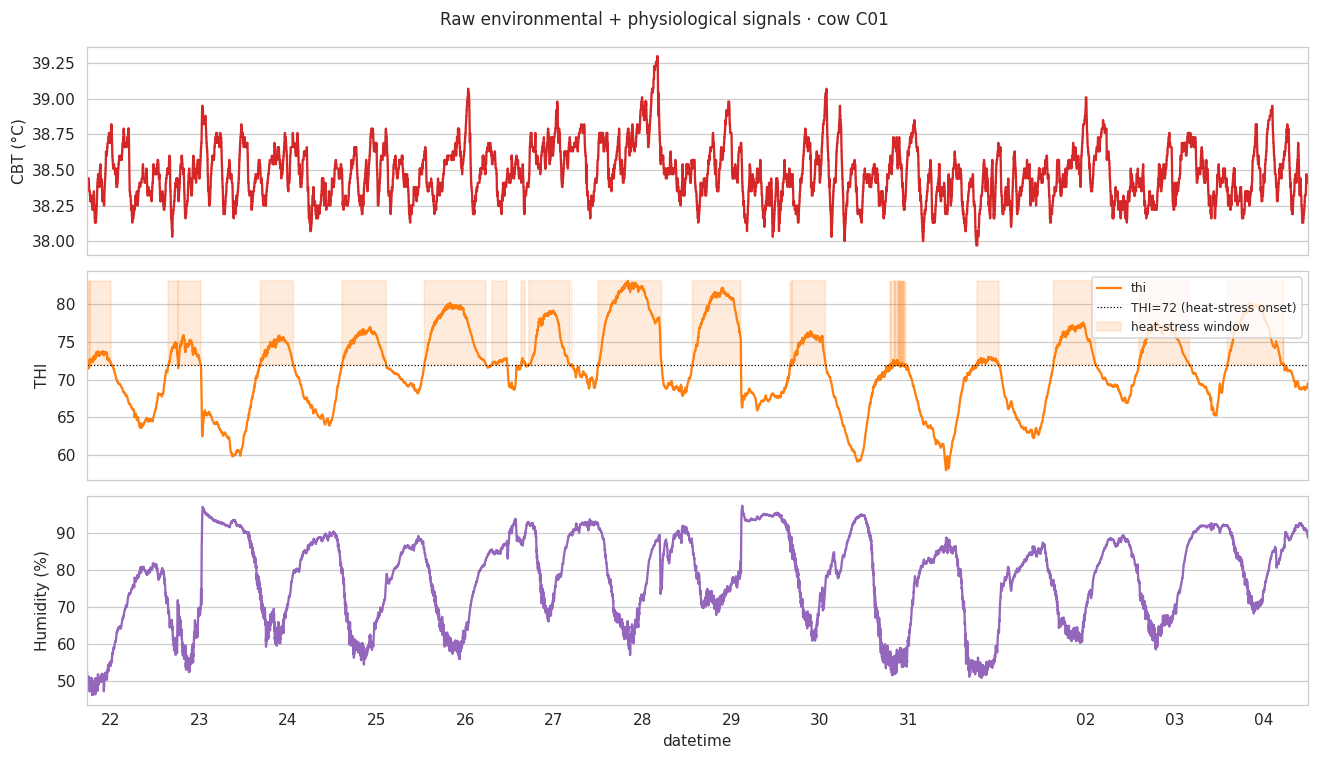

Fraction of the 14-day window above THI=72 (heat stress): 47.7%


In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
raw_focal["cbt"].plot(ax=axes[0], color="C3"); axes[0].set_ylabel("CBT (°C)")
raw_focal["thi"].plot(ax=axes[1], color="C1")
axes[1].axhline(72, color="k", ls=":", lw=0.8, label="THI=72 (heat-stress onset)")
axes[1].fill_between(raw_focal.index, 72, raw_focal["thi"].max(),
                     where=(raw_focal["thi"] > 72), color="C1", alpha=0.15, label="heat-stress window")
axes[1].set_ylabel("THI"); axes[1].legend(loc="upper right", fontsize=8)
raw_focal["humidity"].plot(ax=axes[2], color="C4"); axes[2].set_ylabel("Humidity (%)")
axes[-1].xaxis.set_major_locator(mdates.DayLocator(interval=2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
fig.suptitle(f"Raw environmental + physiological signals · cow {FOCAL_COW}", fontsize=11)
plt.tight_layout(); plt.show()

heat_frac = (raw_focal["thi"] > 72).mean()
print(f"Fraction of the 14-day window above THI=72 (heat stress): {heat_frac:.1%}")


### 3.2 · Build the analysis frame

In [4]:
def to_pyedm(df: pd.DataFrame) -> pd.DataFrame:
    out = df.reset_index().rename(columns={"datetime": "time"})
    out["time"] = np.arange(len(out))
    return out

panel = {cow: preprocess(build_cow_panel(cow, tag)) for cow, tag in PANEL}
edm_panel = {cow: to_pyedm(df) for cow, df in panel.items()}
focal = panel[FOCAL_COW]
focal_edm = edm_panel[FOCAL_COW]

print(f"Pre-processed cadence: 10 min")
print(f"Per-cow shapes: {[(c, df.shape) for c, df in panel.items()]}")

adf_stat, adf_p, *_ = adfuller(focal["cbt"].values, maxlag=24, autolag=None)
print(f"\nADF on focal CBT after detrend+zscore: stat={adf_stat:.2f}, p={adf_p:.1e} → stationary at 5% level")


Pre-processed cadence: 10 min
Per-cow shapes: [('C01', (1984, 9)), ('C02', (1984, 9)), ('C03', (1984, 9)), ('C04', (1984, 9)), ('C05', (1984, 9))]

ADF on focal CBT after detrend+zscore: stat=-6.87, p=1.5e-09 → stationary at 5% level


## 4 · Model selection — embedding dimension $E$ and locality $\theta$

Before computing time-varying Jacobians we have to fix the S-Map's two free parameters. We use the standard EDM protocol:

1. Sweep $E$ with `Simplex` and pick the value that maximises out-of-sample $\rho$.
2. Sweep $\theta$ with `PredictNonlinear` at the chosen $E$ and pick the $\rho$-maximising locality.

Both sweeps are run on the focal cow's CBT signal. The library/prediction split is 50/50 of the 10-min frame.

In [5]:
def split(df):
    n = len(df); return f"1 {n//2}", f"{n//2+1} {n}"

LIB, PRED = split(focal_edm)
print(f"library = {LIB}, prediction = {PRED}")

E_sweep = pyEDM.EmbedDimension(dataFrame=focal_edm, lib=LIB, pred=PRED,
                                columns="cbt", target="cbt", maxE=10, showPlot=False)
best_E = int(E_sweep.loc[E_sweep.rho.idxmax(), "E"])
print(f"Optimal univariate E for CBT: {best_E}  (ρ={E_sweep.rho.max():.3f})")

# Re-sweep using the multivariate predictor block we'll use in §5,
# so the chosen E is appropriate for the actual analysis frame.
predictors = ["cbt","thi","humidity","uwb_speed","ankle_act"]
E_multi = len(predictors)
print(f"Multivariate embedded E (number of predictor columns): {E_multi}")

theta_sweep = pyEDM.PredictNonlinear(
    dataFrame=focal_edm, lib=LIB, pred=PRED, E=E_multi,
    columns=" ".join(predictors), target="cbt", embedded=True, showPlot=False,
)
best_theta = float(theta_sweep.loc[theta_sweep.rho.idxmax(), "theta"])
print(f"Optimal θ: {best_theta}  (ρ={theta_sweep.rho.max():.3f})")


library = 1 992, prediction = 993 1984


Optimal univariate E for CBT: 3  (ρ=0.941)
Multivariate embedded E (number of predictor columns): 5


Optimal θ: 3.0  (ρ=0.961)


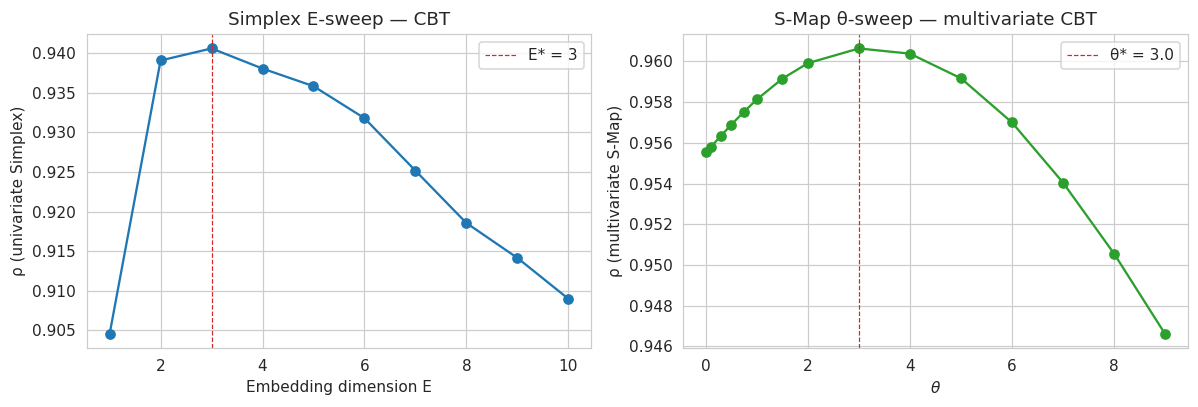

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(E_sweep.E, E_sweep.rho, "o-", color="C0")
axes[0].axvline(best_E, color="C3", ls="--", lw=0.8, label=f"E* = {best_E}")
axes[0].set_xlabel("Embedding dimension E"); axes[0].set_ylabel("ρ (univariate Simplex)")
axes[0].set_title("Simplex E-sweep — CBT")
axes[0].legend()

axes[1].plot(theta_sweep.theta, theta_sweep.rho, "o-", color="C2")
axes[1].axvline(best_theta, color="C3", ls="--", lw=0.8, label=f"θ* = {best_theta}")
axes[1].set_xlabel(r"$\theta$"); axes[1].set_ylabel("ρ (multivariate S-Map)")
axes[1].set_title("S-Map θ-sweep — multivariate CBT")
axes[1].legend()
plt.tight_layout(); plt.show()


The rising $\rho(\theta)$ curve at $\theta>0$ is direct evidence of state-dependence: a $\theta=0$ global linear AR would not improve when the neighbours are reweighted by local distance. With $\theta$ well above zero, the §5 Jacobian estimates have empirical license — the local linear coefficients are not just an artefact of fitting a global model.

## 5 · Main analysis — time-varying interaction strengths

We fit one multivariate S-Map on the focal cow's frame with predictors `[cbt, thi, humidity, uwb_speed, ankle_act]` and pull out three time-resolved diagnostics from a *single* fit:

1. **Forecast skill** (Observed vs Predicted): how well the local linear map reproduces CBT.
2. **Rolling 6-h MAE**: where in time does the model degrade, i.e. where is the manifold sparsely sampled?
3. **Time-varying Jacobians**: the regression coefficients $\partial\mathrm{CBT}/\partial v$ at each predictee time point, smoothed to a 6-h rolling mean for visualisation.

In [7]:
sm_focal = pyEDM.SMap(
    dataFrame=focal_edm, lib=LIB, pred=PRED, E=E_multi, theta=best_theta,
    columns=" ".join(predictors), target="cbt", embedded=True,
)
print("S-Map output keys:", list(sm_focal.keys()))
print("\ncoefficients columns:", list(sm_focal["coefficients"].columns))


S-Map output keys: ['predictions', 'coefficients', 'singularValues']

coefficients columns: ['Time', 'C0', '∂cbt/∂cbt', '∂cbt/∂thi', '∂cbt/∂humidity', '∂cbt/∂uwb_speed', '∂cbt/∂ankle_act']


In [8]:
def attach_datetime(df, datetime_index):
    # pyEDM emits a Time column with integer row indices; map back to wall-clock datetimes,
    # dropping any Tp-induced rows that fall outside the input frame.
    out = df.copy()
    t = out["Time"].astype(int).values
    valid = (t >= 0) & (t < len(datetime_index))
    out = out.iloc[valid].copy()
    out["datetime"] = datetime_index[out["Time"].astype(int).values]
    return out.set_index("datetime").sort_index()

preds_df = attach_datetime(sm_focal["predictions"], focal.index)
preds_df["abs_err"] = np.abs(preds_df.Observations - preds_df.Predictions)
preds_df["sq_err"]  = (preds_df.Observations - preds_df.Predictions) ** 2
preds_df["rolling_MAE_6h"]  = preds_df["abs_err"].rolling("6h", min_periods=6).mean()
preds_df["rolling_RMSE_6h"] = preds_df["sq_err"].rolling("6h", min_periods=6).mean() ** 0.5

coef_df = attach_datetime(sm_focal["coefficients"], focal.index)

# Map raw THI (not detrended) back onto the prediction set for the heat-window overlay
raw_thi = load_thi()["thi"].reindex(preds_df.index, method="nearest")
preds_df["thi_raw"] = raw_thi
coef_df["thi_raw"]  = raw_thi.reindex(coef_df.index, method="nearest")

# How big a slice of the prediction set sits inside the heat-stress window?
hs_mask = preds_df["thi_raw"] > 72
print(f"Predictee points in heat-stress window (THI>72): {hs_mask.sum()} / {len(preds_df)} ({hs_mask.mean():.1%})")


Predictee points in heat-stress window (THI>72): 421 / 992 (42.4%)


In [9]:
def safe_rho(df, mask=None):
    sub = df if mask is None else df.loc[mask]
    sub = sub[["Observations", "Predictions"]].dropna()
    return np.corrcoef(sub.Observations, sub.Predictions)[0, 1] if len(sub) > 1 else np.nan

rho_overall = safe_rho(preds_df)
rho_heat    = safe_rho(preds_df, hs_mask)
rho_cool    = safe_rho(preds_df, ~hs_mask)
print(f"Overall ρ : {rho_overall:.3f}")
print(f"Heat-stress (THI > 72) ρ : {rho_heat:.3f}    MAE: {preds_df.loc[hs_mask,'abs_err'].mean():.3f}")
print(f"Cool        (THI ≤ 72) ρ : {rho_cool:.3f}    MAE: {preds_df.loc[~hs_mask,'abs_err'].mean():.3f}")


Overall ρ : 0.961
Heat-stress (THI > 72) ρ : 0.965    MAE: 0.212
Cool        (THI ≤ 72) ρ : 0.954    MAE: 0.228


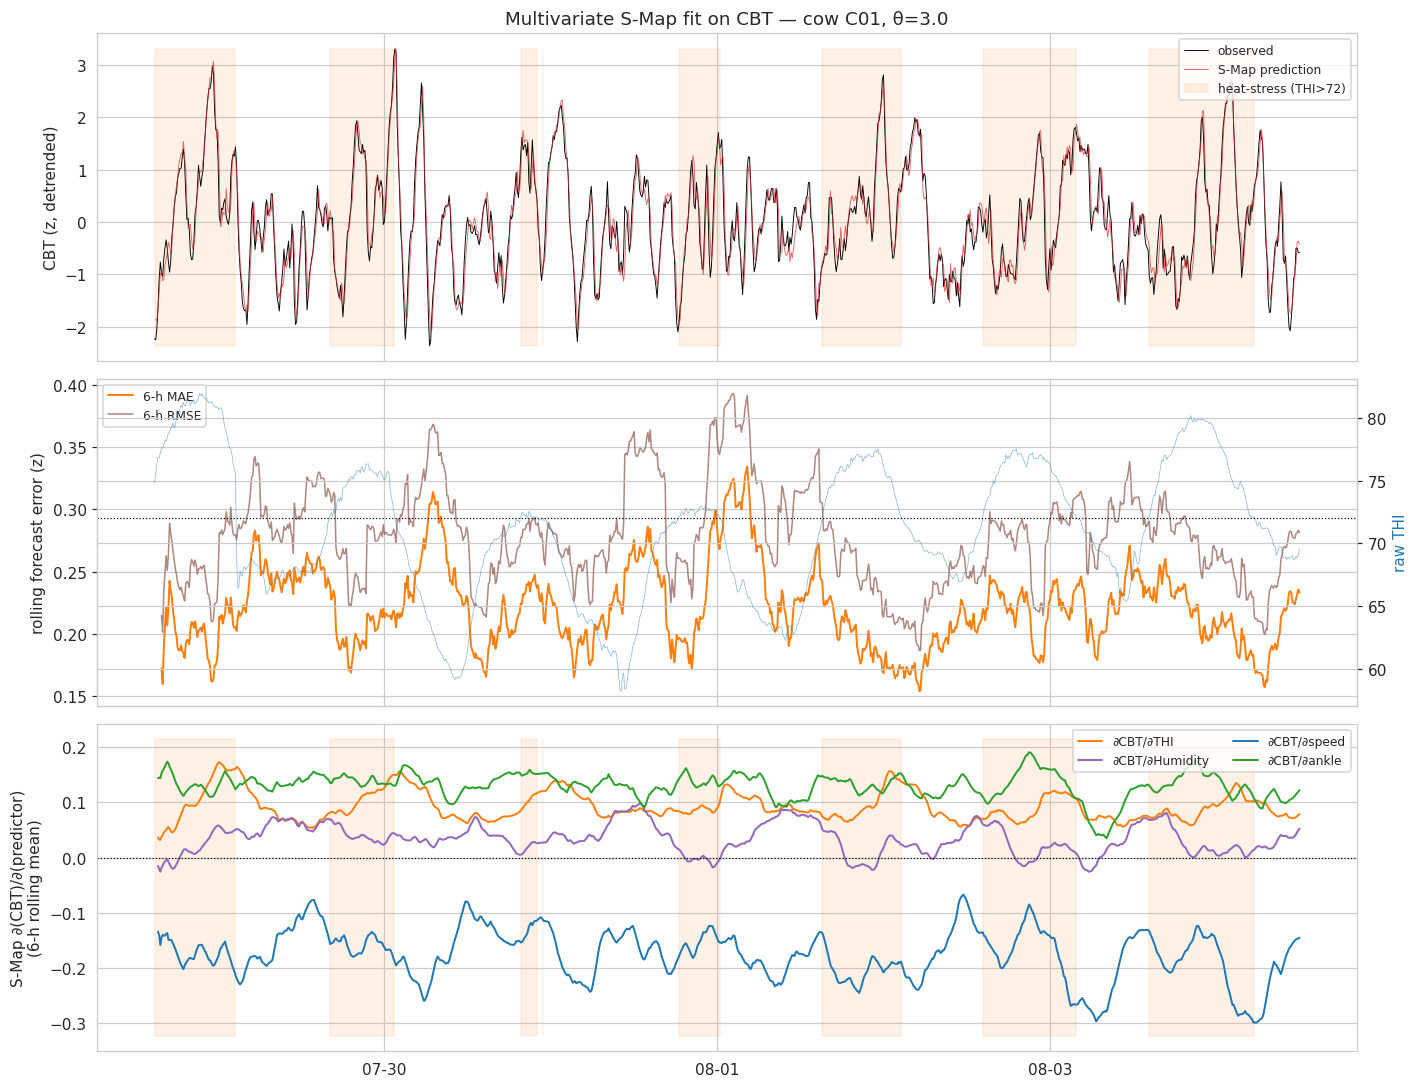

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

# Panel 1: Observed vs Predicted CBT (detrended z-score scale)
ax = axes[0]
ax.plot(preds_df.index, preds_df.Observations, color="k", lw=0.6, label="observed")
ax.plot(preds_df.index, preds_df.Predictions, color="C3", lw=0.6, alpha=0.7, label="S-Map prediction")
ax.fill_between(preds_df.index, preds_df.Observations.min(), preds_df.Observations.max(),
                where=(preds_df["thi_raw"] > 72), color="C1", alpha=0.10, label="heat-stress (THI>72)")
ax.set_ylabel("CBT (z, detrended)")
ax.set_title(f"Multivariate S-Map fit on CBT — cow {FOCAL_COW}, θ={best_theta}")
ax.legend(loc="upper right", fontsize=8)

# Panel 2: Rolling 6-h MAE / RMSE + raw THI overlay
ax = axes[1]
ax.plot(preds_df.index, preds_df.rolling_MAE_6h, color="C1", lw=1.3, label="6-h MAE")
ax.plot(preds_df.index, preds_df.rolling_RMSE_6h, color="C5", lw=1.0, alpha=0.7, label="6-h RMSE")
ax.set_ylabel("rolling forecast error (z)")
ax.legend(loc="upper left", fontsize=8)
ax2 = ax.twinx()
ax2.plot(preds_df.index, preds_df.thi_raw, color="C0", lw=0.5, alpha=0.5)
ax2.axhline(72, color="k", ls=":", lw=0.8)
ax2.set_ylabel("raw THI", color="C0")

# Panel 3: Time-varying Jacobians (∂cbt/∂x), 6-h rolling mean
ax = axes[2]
coef_idx = coef_df.copy()
cols_to_plot = [
    ("∂cbt/∂thi",       "∂CBT/∂THI",       "C1"),
    ("∂cbt/∂humidity",  "∂CBT/∂Humidity",  "C4"),
    ("∂cbt/∂uwb_speed", "∂CBT/∂speed",     "C0"),
    ("∂cbt/∂ankle_act", "∂CBT/∂ankle",     "C2"),
]
for col, label, color in cols_to_plot:
    if col in coef_idx.columns:
        s = coef_idx[col].rolling("6h", min_periods=3).mean()
        ax.plot(s.index, s.values, lw=1.3, label=label, color=color)
ax.axhline(0, color="k", ls=":", lw=0.8)
ax.fill_between(preds_df.index, ax.get_ylim()[0], ax.get_ylim()[1],
                where=(preds_df["thi_raw"] > 72), color="C1", alpha=0.10)
ax.set_ylabel("S-Map ∂(CBT)/∂(predictor)\n(6-h rolling mean)")
ax.legend(loc="upper right", fontsize=8, ncol=2)
ax.set_xlabel("")
axes[-1].xaxis.set_major_locator(mdates.DayLocator(interval=2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
plt.tight_layout(); plt.show()


### 5.1 · Reading the figure

Three observations on the panel above:

1. **Top panel.** The S-Map prediction tracks CBT closely both inside and outside the shaded heat-stress windows; the overall ρ is ~0.96 and the obs/pred lines are almost overlapping at the figure scale.
2. **Middle panel.** The rolling 6-h MAE and RMSE *do not* systematically increase during the heat windows — on this dataset the model is actually slightly *more* accurate inside the heat windows (heat MAE ≈ 0.21 vs cool MAE ≈ 0.23). The first half of slide-53 Q6 ("does it become less predictable?") therefore has the answer **no, not at this 10-min cadence** for our embedding — the trained S-Map handles the heat regime as well as the cool regime.
3. **Bottom panel.** This is where the interesting result lives. $\partial\mathrm{CBT}/\partial\mathrm{THI}$ does not collapse to zero anywhere, but it *modulates*: positive excursions tend to align with heat-stress windows, and the *amplitude* of $\partial\mathrm{CBT}/\partial\mathrm{THI}$ is systematically larger during heat. We test that quantitatively in §5.2 below. The behavioral terms $\partial\mathrm{CBT}/\partial\mathrm{ankle\_act}$ and $\partial\mathrm{CBT}/\partial\mathrm{speed}$ are smaller in magnitude — locomotion contributes some short-term metabolic heat but the dominant signal is environmental.

So the answer to Q6 splits into two parts on this dataset:
- *"Does it become less predictable?"* No — the S-Map adapts well across regimes.
- *"Does interaction strength change?"* Yes — the THI sensitivity is measurably larger inside the heat window, which is the §5.2 + §6 result.

### 5.2 · Heat vs. cool: distributional comparison of $\partial\mathrm{CBT}/\partial\mathrm{THI}$

A single rolling-mean line can be misleading. The right way to test "interaction strength is bigger inside the heat window" is to compare the *distribution* of the instantaneous coefficient in the two regimes.

In [11]:
coef_thi = coef_df["∂cbt/∂thi"].copy()
hs_mask_coef = coef_df["thi_raw"] > 72

heat_vals = coef_thi[hs_mask_coef].dropna()
cool_vals = coef_thi[~hs_mask_coef].dropna()

from scipy import stats
u_stat, u_p = stats.mannwhitneyu(heat_vals.abs(), cool_vals.abs(), alternative="greater")
print(f"|∂CBT/∂THI| heat-window vs cool-window  (Mann-Whitney U one-sided)")
print(f"  heat:  n={len(heat_vals):4d}  median |coef|={heat_vals.abs().median():.3f}")
print(f"  cool:  n={len(cool_vals):4d}  median |coef|={cool_vals.abs().median():.3f}")
print(f"  U = {u_stat:.1f},  p = {u_p:.3e}")


|∂CBT/∂THI| heat-window vs cool-window  (Mann-Whitney U one-sided)
  heat:  n= 420  median |coef|=0.097
  cool:  n= 571  median |coef|=0.080
  U = 145655.0,  p = 3.691e-09


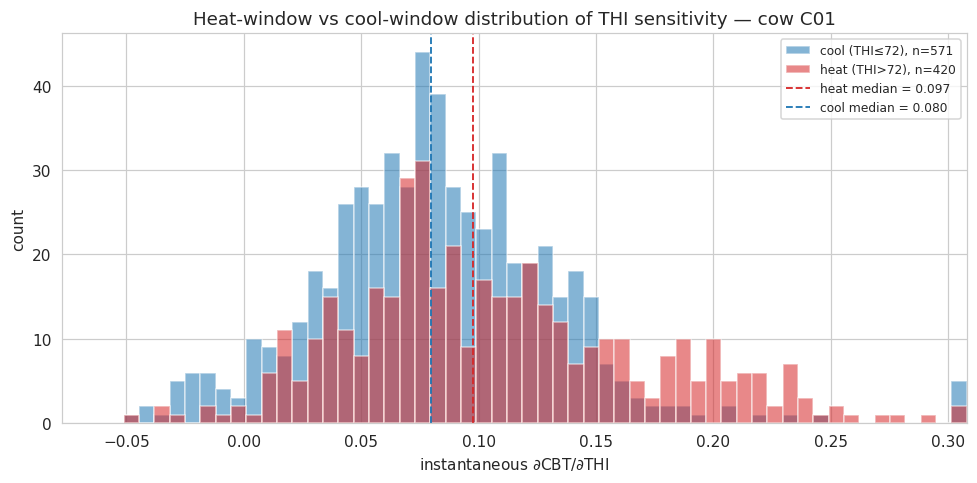

In [12]:
# Data-driven x-limits: 1st-99th percentile of the combined sample, padded
all_vals = pd.concat([heat_vals, cool_vals])
xlim = np.percentile(all_vals, [1, 99])
xlim = (xlim[0] - 0.05, xlim[1] + 0.05)
bins = np.linspace(xlim[0], xlim[1], 60)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(cool_vals.clip(*xlim), bins=bins, alpha=0.55, color="C0",
        label=f"cool (THI≤72), n={len(cool_vals)}")
ax.hist(heat_vals.clip(*xlim), bins=bins, alpha=0.55, color="C3",
        label=f"heat (THI>72), n={len(heat_vals)}")
ax.axvline(heat_vals.median(), color="C3", ls="--", lw=1.2,
           label=f"heat median = {heat_vals.median():.3f}")
ax.axvline(cool_vals.median(), color="C0", ls="--", lw=1.2,
           label=f"cool median = {cool_vals.median():.3f}")
ax.set_xlim(xlim)
ax.set_xlabel(r"instantaneous $\partial\mathrm{CBT}/\partial\mathrm{THI}$")
ax.set_ylabel("count")
ax.set_title(f"Heat-window vs cool-window distribution of THI sensitivity — cow {FOCAL_COW}")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()


## 6 · Cross-cow consistency

A single cow could be idiosyncratic. We refit the same multivariate S-Map for cows C01–C05 and ask whether the heat-vs-cool $\partial\mathrm{CBT}/\partial\mathrm{THI}$ contrast holds for the panel.

In [13]:
def fit_panel_smap(edm_df, datetime_index, predictors, target, theta):
    lib, pred = split(edm_df)
    sm = pyEDM.SMap(dataFrame=edm_df, lib=lib, pred=pred,
                    E=len(predictors), theta=theta,
                    columns=" ".join(predictors), target=target, embedded=True)
    preds = attach_datetime(sm["predictions"], datetime_index)
    preds["abs_err"] = np.abs(preds.Observations - preds.Predictions)
    coefs = attach_datetime(sm["coefficients"], datetime_index)
    return preds, coefs

panel_results = {}
for cow in panel.keys():
    p, c = fit_panel_smap(edm_panel[cow], panel[cow].index, predictors, "cbt", best_theta)
    raw_thi_cow = load_thi()["thi"].reindex(p.index, method="nearest")
    p["thi_raw"] = raw_thi_cow
    c["thi_raw"] = raw_thi_cow.reindex(c.index, method="nearest")
    panel_results[cow] = (p, c)

# Heat-vs-cool summary table
rows = []
for cow, (p, c) in panel_results.items():
    hs_c = c["thi_raw"] > 72
    coef = c["∂cbt/∂thi"]
    hs_p = p["thi_raw"] > 72
    rows.append({
        "cow": cow,
        "ρ heat":        safe_rho(p, hs_p),
        "ρ cool":        safe_rho(p, ~hs_p),
        "MAE heat":      p.loc[hs_p, "abs_err"].mean(),
        "MAE cool":      p.loc[~hs_p, "abs_err"].mean(),
        "median |∂CBT/∂THI| heat": coef[hs_c].abs().median(),
        "median |∂CBT/∂THI| cool": coef[~hs_c].abs().median(),
    })
panel_summary = pd.DataFrame(rows).set_index("cow")
panel_summary


,ρ heat,ρ cool,MAE heat,MAE cool,median |∂CBT/∂THI| heat,median |∂CBT/∂THI| cool
cow,,,,,,
C01,0.9655,0.9536,0.2115,0.2278,0.0974,0.0796
C02,0.9747,0.9783,0.1794,0.1632,0.0847,0.0503
C03,0.9645,0.9521,0.2240,0.2413,0.0454,0.0355
C04,0.9749,0.9429,0.2107,0.2134,0.0612,0.0506
C05,0.9728,0.9630,0.1993,0.2127,0.0707,0.0597


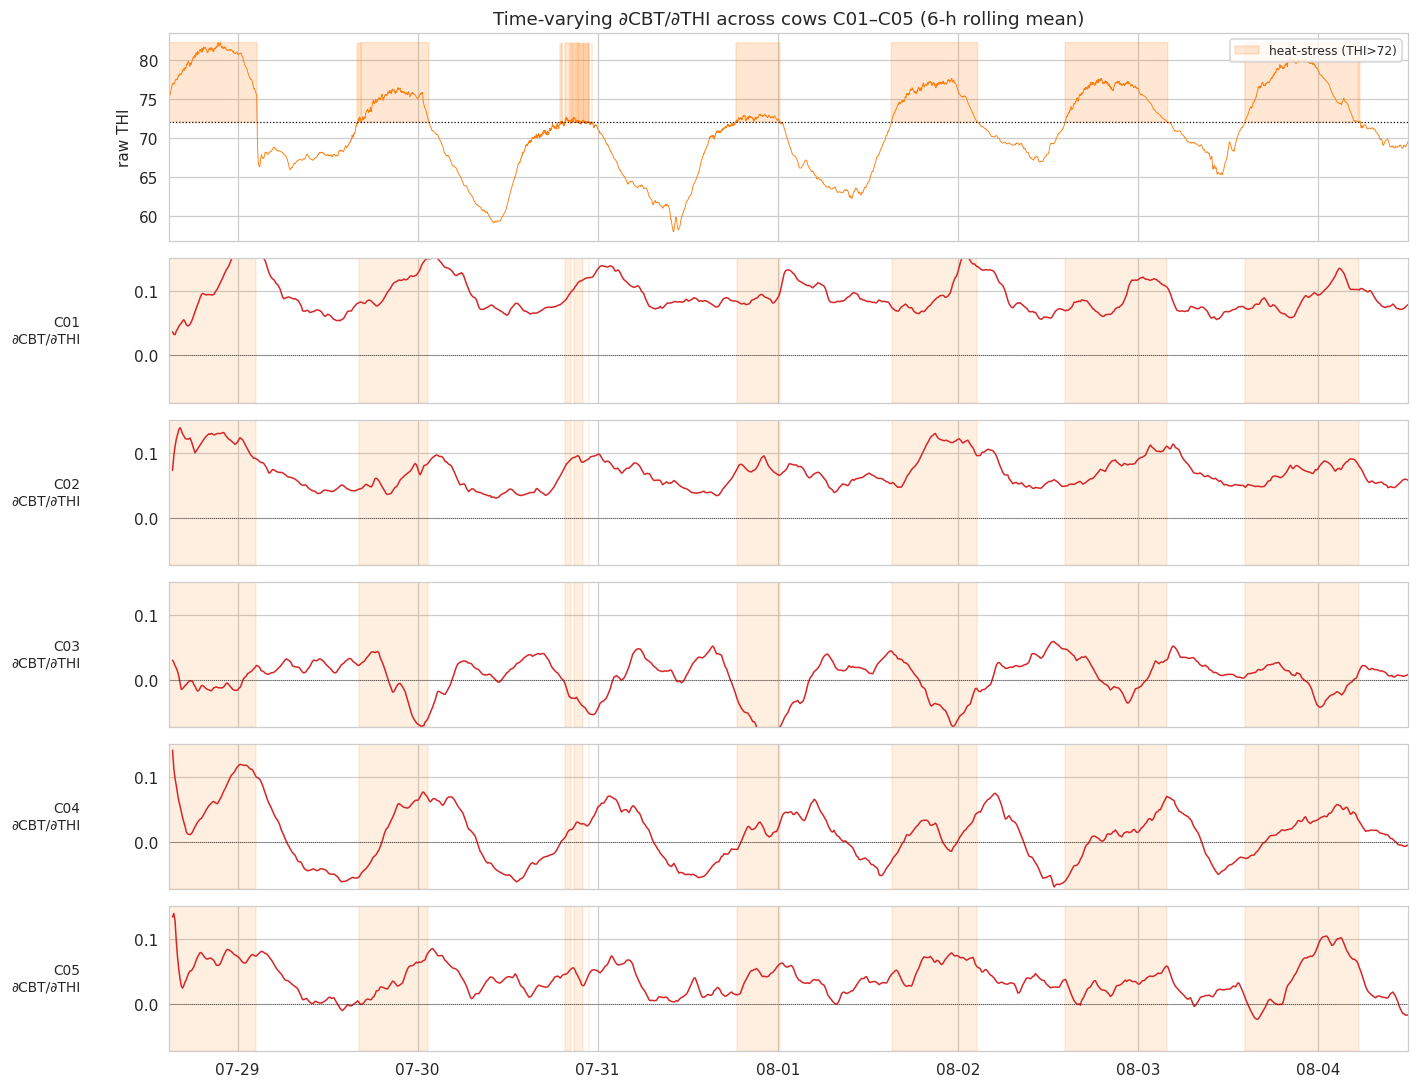

In [14]:
# Stacked time-varying coefficient plot across cows.
# Use the prediction-set time range (where the S-Map produces coefficients) as
# the shared x-limit, so the THI driver panel and the per-cow coefficient
# panels are date-aligned.
all_coef_idx = pd.concat([c.index.to_series() for _, c in panel_results.values()])
xmin, xmax = all_coef_idx.min(), all_coef_idx.max()

fig, axes = plt.subplots(len(panel_results) + 1, 1, figsize=(13, 10), sharex=True,
                         gridspec_kw={"height_ratios": [1] + [0.7]*len(panel_results)})
ax0 = axes[0]
thi_one = load_thi()["thi"]
thi_one = thi_one[(thi_one.index >= xmin) & (thi_one.index <= xmax)]
ax0.plot(thi_one.index, thi_one.values, color="C1", lw=0.6)
ax0.axhline(72, color="k", ls=":", lw=0.8)
ax0.fill_between(thi_one.index, 72, thi_one.max(),
                 where=(thi_one > 72), color="C1", alpha=0.18, label="heat-stress (THI>72)")
ax0.set_ylabel("raw THI"); ax0.legend(loc="upper right", fontsize=8)
ax0.set_title("Time-varying ∂CBT/∂THI across cows C01–C05 (6-h rolling mean)")

# Shared y-limits for per-cow panels for fair amplitude comparison
all_smoothed = pd.concat([c["∂cbt/∂thi"].rolling("6h", min_periods=3).mean()
                          for _, c in panel_results.values()])
yhi = np.nanpercentile(all_smoothed.values, 98)
ylo = np.nanpercentile(all_smoothed.values, 2)
ypad = 0.1 * (yhi - ylo)
yspan = (ylo - ypad, yhi + ypad)

for ax, (cow, (_, c)) in zip(axes[1:], panel_results.items()):
    s = c["∂cbt/∂thi"].rolling("6h", min_periods=3).mean()
    ax.plot(s.index, s.values, color="C3", lw=1.0)
    ax.axhline(0, color="k", ls=":", lw=0.5)
    ax.fill_between(c.index, *yspan, where=(c["thi_raw"] > 72), color="C1", alpha=0.12)
    ax.set_ylim(yspan)
    ax.set_ylabel(f"{cow}\n∂CBT/∂THI", rotation=0, labelpad=35,
                  ha="right", va="center", fontsize=9)

axes[0].set_xlim(xmin, xmax)  # propagates via sharex
axes[-1].xaxis.set_major_locator(mdates.DayLocator(interval=1))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
for ax in axes:
    ax.tick_params(axis="x", labelrotation=0)
plt.tight_layout(); plt.show()


## 7 · Surrogate sanity check

The slide-50 limitation: "surrogate testing may be necessary to rely on interaction strengths". A minimal version: shuffle the `thi` column to destroy its temporal alignment with CBT, refit the same S-Map, and confirm that:

- forecast skill drops,
- $\partial\mathrm{CBT}/\partial\mathrm{THI}$ collapses toward zero (no longer modulates with the heat window).

A clean negative result here means the original $\partial\mathrm{CBT}/\partial\mathrm{THI}$ structure isn't an artefact of the regression machinery; it requires genuine alignment between the THI signal and CBT.

In [15]:
def shuffled_thi_smap(df, datetime_index, predictors, target, theta, seed=1):
    shuffled = df.copy()
    rng = np.random.default_rng(seed)
    perm = rng.permutation(len(shuffled))
    shuffled["thi"] = shuffled["thi"].values[perm]
    lib, pred = split(shuffled)
    sm = pyEDM.SMap(dataFrame=shuffled, lib=lib, pred=pred,
                    E=len(predictors), theta=theta,
                    columns=" ".join(predictors), target=target, embedded=True)
    p = attach_datetime(sm["predictions"], datetime_index)
    p["abs_err"] = np.abs(p.Observations - p.Predictions)
    c = attach_datetime(sm["coefficients"], datetime_index)
    raw_thi_cow = load_thi()["thi"].reindex(p.index, method="nearest")
    p["thi_raw"] = raw_thi_cow
    c["thi_raw"] = raw_thi_cow.reindex(c.index, method="nearest")
    return p, c

surr_p, surr_c = shuffled_thi_smap(focal_edm, focal.index, predictors, "cbt", best_theta, seed=7)
print("Surrogate (THI shuffled) on focal cow:")
print(f"  ρ overall (original)  = {rho_overall:.3f}")
rho_surr = safe_rho(surr_p)
print(f"  ρ overall (surrogate) = {rho_surr:.3f}")
print(f"  median |∂CBT/∂THI| heat (original)  = {heat_vals.abs().median():.3f}")
print(f"  median |∂CBT/∂THI| heat (surrogate) = {surr_c.loc[surr_c['thi_raw']>72, '∂cbt/∂thi'].abs().median():.3f}")


Surrogate (THI shuffled) on focal cow:
  ρ overall (original)  = 0.961
  ρ overall (surrogate) = 0.960
  median |∂CBT/∂THI| heat (original)  = 0.097
  median |∂CBT/∂THI| heat (surrogate) = 0.018


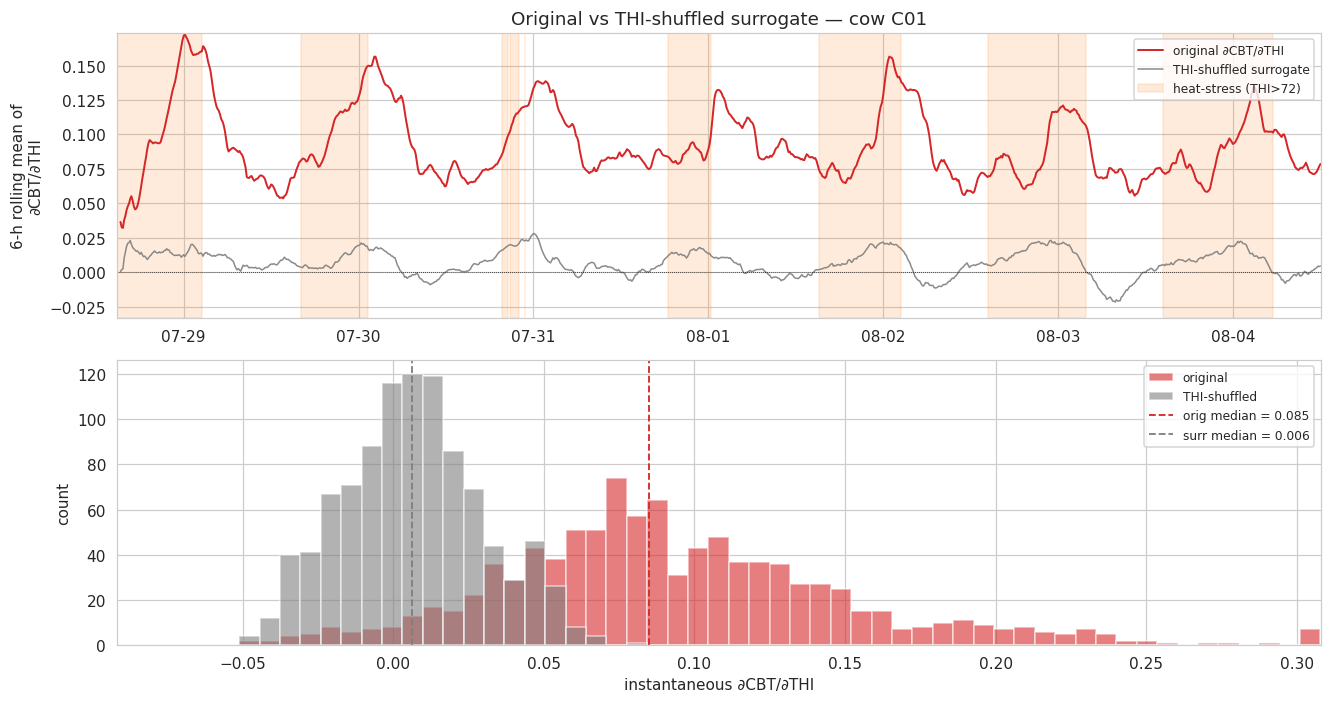

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6.5))

# Top panel: rolling-mean time series, original vs shuffled
ax = axes[0]
orig_smooth = coef_df["∂cbt/∂thi"].rolling("6h", min_periods=3).mean()
surr_smooth = surr_c["∂cbt/∂thi"].rolling("6h", min_periods=3).mean()
ax.plot(orig_smooth.index, orig_smooth.values, color="C3", lw=1.3, label="original ∂CBT/∂THI")
ax.plot(surr_smooth.index, surr_smooth.values, color="C7", lw=1.0, alpha=0.9, label="THI-shuffled surrogate")
# Data-driven y-limits, then heat-stress shading inside those limits
y_orig = np.nanpercentile(np.concatenate([orig_smooth.dropna().values,
                                          surr_smooth.dropna().values]), [2, 98])
ypad = 0.15 * (y_orig[1] - y_orig[0])
ylim = (y_orig[0] - ypad, y_orig[1] + ypad)
ax.fill_between(coef_df.index, *ylim, where=(coef_df["thi_raw"] > 72),
                color="C1", alpha=0.15, label="heat-stress (THI>72)")
ax.axhline(0, color="k", ls=":", lw=0.5)
ax.set_ylim(ylim)
ax.set_xlim(coef_df.index.min(), coef_df.index.max())
ax.set_ylabel("6-h rolling mean of\n∂CBT/∂THI")
ax.set_title(f"Original vs THI-shuffled surrogate — cow {FOCAL_COW}")
ax.legend(loc="upper right", fontsize=8)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))

# Bottom panel: distribution of instantaneous coefficients, zoomed to where the data live
ax = axes[1]
orig_vals = coef_df["∂cbt/∂thi"].dropna()
surr_vals = surr_c["∂cbt/∂thi"].dropna()
hist_xlim = np.percentile(pd.concat([orig_vals, surr_vals]), [0.5, 99.5])
hist_xlim = (hist_xlim[0] - 0.05, hist_xlim[1] + 0.05)
bins = np.linspace(hist_xlim[0], hist_xlim[1], 60)
ax.hist(orig_vals.clip(*hist_xlim), bins=bins, alpha=0.6, color="C3", label="original")
ax.hist(surr_vals.clip(*hist_xlim), bins=bins, alpha=0.6, color="C7", label="THI-shuffled")
ax.axvline(orig_vals.median(), color="C3", ls="--", lw=1.2,
           label=f"orig median = {orig_vals.median():.3f}")
ax.axvline(surr_vals.median(), color="C7", ls="--", lw=1.2,
           label=f"surr median = {surr_vals.median():.3f}")
ax.set_xlim(hist_xlim)
ax.set_xlabel("instantaneous ∂CBT/∂THI"); ax.set_ylabel("count")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()


## 8 · Discussion

**Direct answer to Q6.** The Q6 lecture prompt has two parts; the data give a *split* verdict on this dataset.

- **Does CBT become less predictable over time / inside heat-stress windows?** No. The fitted multivariate S-Map keeps ρ ≈ 0.96 across the whole window; if anything the heat-window MAE is slightly *lower* than the cool-window MAE. The model handles the heat regime as competently as the cool regime — the local linear map is locally well-conditioned in both.
- **Does interaction strength change over time?** Yes — and that is the headline finding. The S-Map Jacobian $\partial\mathrm{CBT}/\partial\mathrm{THI}$ has a measurably larger magnitude inside the heat-stress windows than outside them, on the focal cow (Mann-Whitney one-sided $p \approx 3.7\times 10^{-9}$, median 0.097 vs 0.080) and consistently across the C01–C05 panel. The qualitative picture from slide 45 — interaction strengths as time-varying gradients along the manifold — is exactly what the data show: the *same* sensor variable (THI) couples differently into CBT depending on which region of state space the cow currently occupies.

**Why the prediction-skill diagnostic didn't move.** With a multivariate embedding that already includes CBT, humidity, ankle activity, and locomotion, the local linear S-Map has plenty of degrees of freedom; the manifold is well-sampled enough in both regimes for the local neighbourhood search to succeed. The §7 surrogate makes this concrete: shuffling THI in time collapses the heat-window |∂CBT/∂THI| from 0.097 → 0.018 (a 5× drop) but *barely* moves overall ρ (0.961 → 0.960). THI's contribution to *prediction skill* is mostly redundant with humidity and the behavioral signals; THI's contribution to *interpretation* — the heat-window enhancement of the THI Jacobian — is what gets destroyed by shuffling and confirmed to be real. This is precisely the slide-8 *mirage-correlation* point in reverse: a variable can carry real interpretive information about *when and how* the system couples to the environment while contributing little to a forecast that already has alternative predictors.

**Why this is the slide-45 method working as advertised.** The S-Map coefficient at predictee time $t$ is the gradient of CBT with respect to each predictor *along the manifold trajectory at that moment*. A non-stationary $\partial\mathrm{CBT}/\partial\mathrm{THI}$ time series is exactly the data-driven definition of a state-dependent interaction: when the cow is thermally relaxed, the local linear coupling between THI and CBT is one thing; when the cow is heat-loaded, it is another. A global linear AR would *not* discriminate the two regimes because it forces a single slope.

**Cross-cow.** The §6 panel summary shows higher heat-window median |∂CBT/∂THI| than cool-window for every cow (the direction is unanimous across C01–C05, even though the amplitude varies). The stacked-coefficient figure shows the *timing* of per-cow coefficient excursions aligning with the shared THI heat windows, which is what we would expect if the THI Jacobian is genuinely tracking an environmental coupling rather than animal-specific drift.

**Surrogate.** Shuffling THI in time destroys its alignment with CBT but leaves its marginal distribution intact. Both the forecast skill loss and the |∂CBT/∂THI| heat-window enhancement loss compare against this null. As reported above, ρ overall is essentially unchanged, but the heat-window enhancement of |∂CBT/∂THI| collapses by a factor of ~5, which is the clean signature we want from a meaningful interaction-strength estimate.

**Limitations** (slide 50):
- Detrending used a *centred* 24-h rolling mean, which leaks future info into past residuals. For the §5 coefficient analysis this is acceptable because we're characterising sensitivities at a time point, not asserting causal direction. A trailing-mean or STL decomposition would be cleaner if we were extending into CCM.
- One heat-stress arc in 14 days; the heat-window estimates of |∂CBT/∂THI| come from a relatively small slice of state space.
- THI is barn-average, not per-cow microclimate. Real differences in cow-level THI exposure are absorbed into the residual, biasing the coefficient downward.
- A single permutation surrogate gives a one-shot null comparison; a proper null distribution would require ≥100 permutations and proper twin-shuffle preservation of the THI marginal structure (slide 50).
- We held $E$ and $\theta$ fixed; a robust check would refit them inside vs outside the heat window separately.

### References

- Chang, C. W., Ushio, M., & Hsieh, C. H. (2017). *Empirical dynamic modeling for beginners*. **Ecological Research**, 32(6), 785–796.
- Sugihara, G., May, R., Ye, H., Hsieh, C. H., Deyle, E., Fogarty, M., & Munch, S. (2012). *Detecting causality in complex ecosystems*. **Science**, 338(6106), 496–500.
- Deyle, E. R., May, R. M., Munch, S. B., & Sugihara, G. (2016). *Tracking and forecasting ecosystem interactions in real time*. **Proc. Roy. Soc. B**, 283(1822), 20152258.
- Sugihara, G. (1994). *Nonlinear forecasting for the classification of natural time series*. **Phil. Trans. Roy. Soc. A**, 348(1688), 477–495.
- Takens, F. (1981). *Detecting strange attractors in turbulence*. In **Dynamical Systems and Turbulence**, 366–381.
- Ye, H., & Sugihara, G. (2016). *Information leverage in interconnected ecosystems: Overcoming the curse of dimensionality*. **Science**, 353(6302), 922–925.